# 02 — Context Engineering in Deep Agents

**来源:** [LangChain Docs — Context Engineering](https://docs.langchain.com/oss/python/deepagents/context-engineering)

Context Engineering = 让 Agent 在正确的时间访问正确的上下文，完成可靠的长任务。

## 五种上下文类型一览

| 类型 | 控制什么 | 作用域 |
|------|----------|--------|
| **Input Context** | system prompt, memory, skills, tool prompts | 静态，每次运行生效 |
| **Runtime Context** | 调用时传入的用户元数据、API Key、连接信息 | 每次调用，自动传播到子 Agent |
| **Context Compression** | 内置的 offloading 与 summarization | 自动触发，接近窗口限制时 |
| **Context Isolation** | Subagent 隔离重型任务，只返回结果给主 Agent | 每次委派时 |
| **Long-term Memory** | 通过虚拟文件系统实现跨线程持久化 | 跨对话持久化 |

## 1. Input Context（输入上下文）

启动时注入 Agent 的信息，成为 System Prompt 的一部分。

### 1.1 System Prompt

核心方式：通过 `system_prompt` 参数设定角色与行为。


动态 prompt：
- `@dynamic_prompt` 装饰器 — 基于 `runtime.context` 或 `runtime.store` 运行时修改
- `base_system_prompt` / `system_prompt_suffix` — 分层组合（HarnessProfile 覆盖）

In [3]:
from deepagents import create_deep_agent
from dotenv import load_dotenv

load_dotenv()

agent = create_deep_agent(
    model="deepseek-v4-flash",
    system_prompt=(
        "你是一名专门研究科学文献的研究助理。始终引用来源。使用子代理进行不同主题的并行研究。"
    ),
)

### 1.2 Memory（AGENTS.md）

项目根目录的 `AGENTS.md` 或其他文件，**始终加载**到 system prompt 中。

> **注意：** 没有渐进式披露（always injected），保持内容精简。详细工作流应放在 skills 中。

In [ ]:
agent = create_deep_agent(
    model="google_genai:gemini-3.5-flash",
    memory=["/project/AGENTS.md", "~/.deepagents/preferences.md"],
)

### 1.3 Skills（SKILL.md）

按需加载的技能目录。Agent 启动时只读 frontmatter，认为相关时才加载完整内容（渐进式披露）。

> 每个 skill 聚焦单一领域，详细参考资料放到单独文件。

In [ ]:
agent = create_deep_agent(
    model="deepseek-v4-flash",
    skills=["/skills/research/", "/skills/web-search/"],
)

### 1.4 Tool Prompts

工具的 Docstring 就是它的 Prompt。用 `@tool(parse_docstring=True)` 获得丰富描述。

额外控制：
- `tool_description_overrides` — 覆写工具描述
- `excluded_tools` — 排除不需要的工具

In [ ]:
from langchain_core.tools import tool

@tool(parse_docstring=True)
def search_orders(
    user_id: str,
    status: str,
    limit: int = 10
) -> str:
    """Search for user orders by status.

    Use this when the user asks about order history or wants to check
    order status. Always filter by the provided status.

    Args:
        user_id: Unique identifier for the user
        status: Order status: 'pending', 'shipped', or 'delivered'
        limit: Maximum number of results to return
    """

### 1.5 完整 System Prompt 组装顺序

最终注入 Agent 的完整 prompt 按以下顺序拼接：

1. 自定义 `system_prompt`
2. Base agent prompt（SDK 默认）
3. To-do list prompt
4. Memory prompt（如果设置了 `memory`）
5. Skills prompt（如果设置了 `skills`）
6. 虚拟文件系统 prompt
7. Subagent prompt
8. 用户提供的 middleware prompts
9. Human-in-the-loop prompt（如果设置了 `interrupt_on`）

## 2. Runtime Context（运行时上下文）

在 `invoke()` / `ainvoke()` 调用时传入的静态配置，**不会自动出现在 prompt 中**，需要 tool 或 middleware 主动读取。

关键 API：
- 定义 `context_schema`（dataclass 或 TypedDict）
- 在 tool 中通过 `ToolRuntime[Context]` 访问 `runtime.context`
- 自动传播到所有 subagent

In [1]:
from dataclasses import dataclass
from dotenv import load_dotenv
from deepagents import create_deep_agent
from langchain.tools import tool, ToolRuntime
from langchain.chat_models import init_chat_model

load_dotenv()

# ---------- 定义上下文结构 ----------
@dataclass
class UserContext:
    user_id: str
    user_name: str

# ---------- 工具中读取 Runtime Context ----------
@tool
def greet_user(runtime: ToolRuntime[UserContext]) -> str:
    """获取当前用户信息并打招呼"""
    uid = runtime.context.user_id
    name = runtime.context.user_name
    return f"你好 {name}（{uid}）！欢迎回来。"

# ---------- 创建 Agent ----------
model = init_chat_model("deepseek-v4-flash")
agent = create_deep_agent(
    model=model,
    tools=[greet_user],
    context_schema=UserContext,
    system_prompt="你是体贴的个人助手。用 greet_user 了解用户信息。",
)

print("Agent 创建完成，运行下方 cell 测试")

Agent 创建完成，运行下方 cell 测试


In [2]:
# ---------- 调用测试 ----------
result = agent.invoke(
    {"messages": [{"role": "user", "content": "先获取我的信息，然后打个招呼"}]},
    context=UserContext(user_id="u-1001", user_name="张三"),
)

print(result["messages"][-1].content)

你好，张三（u-1001）！很高兴为你服务，有什么需要帮忙的吗？


### Custom State Schema（≥ deepagents 0.6.6）

如果需要**可变的、可持久化的图形状态**（不仅仅是只读上下文），用 `state_schema`：

- 继承 `DeepAgentState` 保持 `DeltaChannel` reducer
- 在 tool 中通过 `runtime.state["key"]` 读写
- 支持 checkpoint 和流式传输

In [ ]:
# from deepagents import DeepAgentState, create_deep_agent
#
# class ResearchState(DeepAgentState):
#     page_url: str
#     file_urls: list[str]
#
# @tool
# def cite_page(runtime: ToolRuntime) -> str:
#     """返回当前页面 URL"""
#     return runtime.state["page_url"]
#
# agent = create_deep_agent(
#     model="deepseek-v4-flash",
#     tools=[cite_page],
#     state_schema=ResearchState,
# )

## 3. Context Compression（上下文压缩）

### Offloading（自动卸载）

当输入或工具响应过大时，系统自动将内容保存到磁盘，prompt 中只保留：
- 前 10 行 + 文件位置提示
- 大型工具响应的占位符

### Summarization（自动摘要）

当对话超过 `max_input_tokens` 时，自动 summarization 旧轮次。

流式输出时过滤 summarization token：

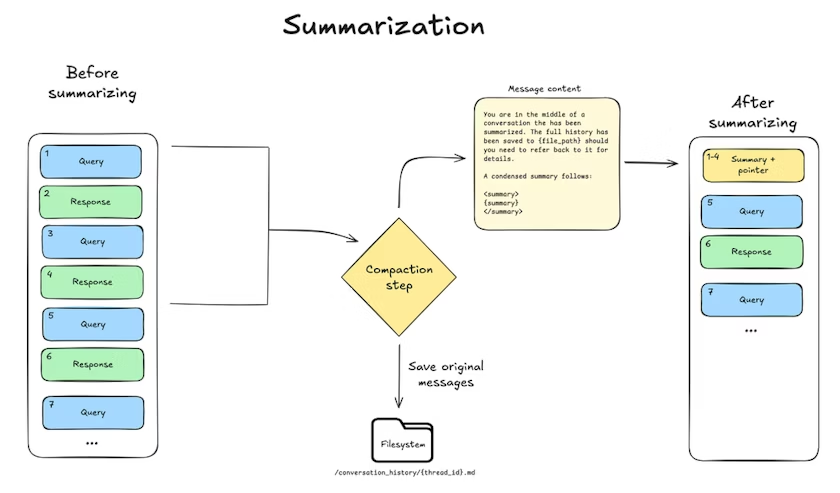

In [ ]:
for chunk in agent.stream(
    {"messages": [...]},
    stream_mode="messages",
    version="v2",
):
    token, metadata = chunk["data"]
    if metadata.get("lc_source") == "summarization":
        continue  # 跳过摘要 token
    else:
        print(token, end="")

### Summarization Tool Middleware

提供独立的摘要中间件，让 Agent 主动调用摘要工具压缩上下文：

In [7]:
from deepagents.middleware.summarization import create_summarization_tool_middleware
from deepagents.backends import StateBackend

tool_middleware = create_summarization_tool_middleware(
    model="deepseek-v4-flash",backend=StateBackend
)

agent = create_deep_agent(
    model=model,
    middleware=[tool_middleware],
)

## 4. Context Isolation（上下文隔离 — Subagent）

Subagent 是**隔离重型任务的核心手段**：
- Subagent 有自己的模型、tools、middleware
- 主 Agent 只接收 subagent 返回的结果摘要
- 减少主 Agent 的上下文污染

In [ ]:
from deepagents import SubAgent

research_subagent = SubAgent(
    model="deepseek-v4-flash",
    name="researcher",
    system_prompt="你是研究员，搜索并总结资料。只返回结论。"
)

agent = create_deep_agent(
    model=model,
    subagents=[research_subagent],
)

## 5. Long-Term Memory（长期记忆）

通过虚拟文件系统实现跨对话持久化：
- `write_file` 将重要信息写入文件
- 下次对话通过 `read_file` 读取
- 可配合 memory 参数在启动时自动加载

```python
# Agent 可以在对话中主动保存重要信息
# 用户: "记住我的邮箱是 zhangsan@example.com"
# Agent: 调用 write_file("user_preferences.md", "邮箱: zhangsan@example.com")

# 下次对话时加载
agent = create_deep_agent(
    model="deepseek-v4-flash",
    memory=["./user_preferences.md"],
)
```

## 最佳实践总结

| 场景 | 推荐方式 |
|------|----------|
| 静态角色/规则 | `system_prompt` |
| 项目级惯例 | `memory=["AGENTS.md"]` |
| 按需技能 | `skills=["/skills/..."]`（渐进式披露） |
| 调用时用户信息 | `context_schema` + `runtime.context` |
| 可变图形状态（≥0.6.6） | `state_schema` + `runtime.state` |
| 长对话上下文控制 | `max_input_tokens` + summarization |
| 重型任务隔离 | Subagent |
| 跨对话持久化 | 虚拟文件系统 + `memory` |

---
**参考链接**

- [Context Engineering — LangChain Docs](https://docs.langchain.com/oss/python/deepagents/context-engineering)
- [Documentation Index](https://docs.langchain.com/llms.txt)
- [Deep Agents Customization](https://docs.langchain.com/oss/python/deepagents/customization)